# Comparative Analysis of FCN-ResNet50 and DeepLabV3+ for Semantic Segmentation on SENSATION and CamVid Datasets

## Abstract

This project presents a comparative study of two semantic segmentation architectures: FCN-ResNet50 and DeepLabV3+. The experiments are conducted on the SENSATION and CamVid datasets to evaluate segmentation performance in urban scene understanding. Both models are trained and evaluated using the same preprocessing pipeline, dataset split strategy, optimization settings, and evaluation metrics to ensure a fair comparison.

The evaluation includes Pixel Accuracy, Mean Intersection over Union, Dice Score, Precision, Recall, and Inference Time. Quantitative results are supported by qualitative visualizations of predicted segmentation masks and overlays. The study discusses the strengths, limitations, computational cost, and segmentation behavior of both architectures.

## Imports

In [2]:
from pathlib import Path
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Project directories
PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
REPORTS_DIR = PROJECT_ROOT / "reports"

for directory in [OUTPUTS_DIR, CHECKPOINTS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Using device: {DEVICE}")

if DEVICE.type == "cpu":
    print("Warning: CUDA is not available. Full training may be slow on CPU.")

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Using device: cuda


## Dataset Configuration

The initial experiments are conducted on the CamVid dataset because it is smaller than SENSATION and suitable for validating the complete experimental pipeline. CamVid consists of urban driving scenes with pixel-level semantic annotations. The dataset is already divided into training, validation, and test subsets.

The mask files are stored as class-index PNG images, where each pixel value corresponds to a semantic class. The `Unlabelled` class is treated as an ignored class during loss calculation and metric computation because it does not represent a meaningful semantic category.

In [3]:
# Dataset 1: CamVid
# Active datasets for the current experiment
ACTIVE_DATASETS = ["camvid"]

# CamVid dataset paths
CAMVID_ROOT = DATA_DIR / "camvid"

CAMVID_IMAGE_DIRS = {
    "train": CAMVID_ROOT / "images" / "train",
    "val": CAMVID_ROOT / "images" / "val",
    "test": CAMVID_ROOT / "images" / "test",
}

CAMVID_MASK_DIRS = {
    "train": CAMVID_ROOT / "masks" / "train",
    "val": CAMVID_ROOT / "masks" / "val",
    "test": CAMVID_ROOT / "masks" / "test",
}

# Standard CamVid 12-class setup used by many semantic segmentation implementations.
# The final class, Unlabelled, is treated as ignore/void.
CAMVID_CLASSES = {
    0: "Sky",
    1: "Building",
    2: "Pole",
    3: "Road",
    4: "Pavement",
    5: "Tree",
    6: "SignSymbol",
    7: "Fence",
    8: "Car",
    9: "Pedestrian",
    10: "Bicyclist",
    11: "Unlabelled",
}

CAMVID_NUM_CLASSES = len(CAMVID_CLASSES)
CAMVID_IGNORE_INDEX = 11

# Training configuration for the small CamVid experiment
IMAGE_SIZE = 384
BATCH_SIZE = 2
NUM_WORKERS = 0

print(f"CamVid classes: {CAMVID_NUM_CLASSES}")
print(f"Ignored class index: {CAMVID_IGNORE_INDEX} ({CAMVID_CLASSES[CAMVID_IGNORE_INDEX]})")

# Dataset 2: SENSATION
SENSATION_ROOT = DATA_DIR / "sensation"

SENSATION_IMAGE_DIRS = {
    "train": SENSATION_ROOT / "images" / "train",
    "val": SENSATION_ROOT / "images" / "val",
    "test": SENSATION_ROOT / "images" / "test",
}

SENSATION_MASK_DIRS = {
    "train": SENSATION_ROOT / "masks" / "train",
    "val": SENSATION_ROOT / "masks" / "val",
    "test": SENSATION_ROOT / "masks" / "test",
}

# Placeholder class mapping based on the project specification.
# Verify these labels against the official SENSATION annotation documentation
# before final training and reporting.
SENSATION_CLASSES = {
    0: "background",
    1: "road",
    2: "sidewalk",
    3: "crosswalk",
    4: "bikelane",
    5: "person",
    6: "car",
    7: "bicycle",
    8: "traffic sign",
    9: "traffic light",
    10: "obstacle",
    11: "stairs",
}

SENSATION_NUM_CLASSES = len(SENSATION_CLASSES)

# Set this to an integer if the SENSATION dataset has a void/unlabelled class.
# Keep as None if all classes should be used for loss and metrics.
SENSATION_IGNORE_INDEX = None

print("SENSATION dataset is configured but not active yet.")
print(f"SENSATION expected classes: {SENSATION_NUM_CLASSES}")

CamVid classes: 12
Ignored class index: 11 (Unlabelled)
SENSATION dataset is configured but not active yet.
SENSATION expected classes: 12


In [4]:
def verify_segmentation_structure(
    image_dirs: dict[str, Path],
    mask_dirs: dict[str, Path],
    dataset_name: str,
) -> pd.DataFrame:
    rows = []

    for split in ["train", "val", "test"]:
        image_dir = image_dirs[split]
        mask_dir = mask_dirs[split]

        if not image_dir.exists() or not mask_dir.exists():
            rows.append({
                "dataset": dataset_name,
                "split": split,
                "images": 0,
                "masks": 0,
                "matched_pairs": 0,
                "missing_masks": "folder missing",
                "missing_images": "folder missing",
            })
            continue

        image_files = sorted(image_dir.glob("*.png"))
        mask_files = sorted(mask_dir.glob("*.png"))

        image_names = {p.name for p in image_files}
        mask_names = {p.name for p in mask_files}

        missing_masks = sorted(image_names - mask_names)
        missing_images = sorted(mask_names - image_names)

        rows.append({
            "dataset": dataset_name,
            "split": split,
            "images": len(image_files),
            "masks": len(mask_files),
            "matched_pairs": len(image_names & mask_names),
            "missing_masks": len(missing_masks),
            "missing_images": len(missing_images),
        })

    return pd.DataFrame(rows)


def inspect_dataset_mask_values(
    mask_dirs: dict[str, Path],
    dataset_name: str,
) -> list[int] | None:
    existing_mask_files = []

    for split in ["train", "val", "test"]:
        mask_dir = mask_dirs[split]

        if mask_dir.exists():
            existing_mask_files.extend(sorted(mask_dir.glob("*.png")))

    if not existing_mask_files:
        print(f"{dataset_name}: no mask files found yet.")
        return None

    values = set()

    for mask_path in existing_mask_files:
        mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)

        if mask is None:
            raise ValueError(f"Could not read mask: {mask_path}")

        if mask.ndim == 3:
            print(
                f"{dataset_name}: RGB/color mask detected at {mask_path.name}. "
                "A color-to-class mapping will be required."
            )
            return None

        values.update(np.unique(mask).astype(int).tolist())

    return sorted(values)

In [5]:
# Verify CamVid
camvid_summary = verify_segmentation_structure(
    CAMVID_IMAGE_DIRS,
    CAMVID_MASK_DIRS,
    dataset_name="CamVid",
)

display(camvid_summary)

camvid_mask_values = inspect_dataset_mask_values(
    CAMVID_MASK_DIRS,
    dataset_name="CamVid",
)

print("CamVid mask values:", camvid_mask_values)

# Verify SENSATION
sensation_summary = verify_segmentation_structure(
    SENSATION_IMAGE_DIRS,
    SENSATION_MASK_DIRS,
    dataset_name="SENSATION",
)

display(sensation_summary)

sensation_mask_values = inspect_dataset_mask_values(
    SENSATION_MASK_DIRS,
    dataset_name="SENSATION",
)

print("SENSATION mask values:", sensation_mask_values)

,dataset,split,images,masks,matched_pairs,missing_masks,missing_images
0,CamVid,train,367,367,367,0,0
1,CamVid,val,101,101,101,0,0
2,CamVid,test,233,233,233,0,0


CamVid mask values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


,dataset,split,images,masks,matched_pairs,missing_masks,missing_images
0,SENSATION,train,0,0,0,folder missing,folder missing
1,SENSATION,val,0,0,0,folder missing,folder missing
2,SENSATION,test,0,0,0,folder missing,folder missing


SENSATION: no mask files found yet.
SENSATION mask values: None


## Visual Verification of Image-Mask Alignment

Before model training, image-mask alignment is verified visually. This step is essential because semantic segmentation uses pixel-level supervision. If an image is paired with the wrong mask, or if the mask is spatially misaligned, the training process becomes invalid.

A sample CamVid image is displayed together with its raw class-index mask, a colorized semantic mask, and an overlay visualization.

In [6]:
DATASET_CONFIGS = {
    "camvid": {
        "name": "CamVid",
        "image_dirs": CAMVID_IMAGE_DIRS,
        "mask_dirs": CAMVID_MASK_DIRS,
        "classes": CAMVID_CLASSES,
        "num_classes": CAMVID_NUM_CLASSES,
        "ignore_index": CAMVID_IGNORE_INDEX,
        "palette": {
            0: (128, 128, 128),   # Sky
            1: (128, 0, 0),       # Building
            2: (192, 192, 128),   # Pole
            3: (128, 64, 128),    # Road
            4: (60, 40, 222),     # Pavement
            5: (128, 128, 0),     # Tree
            6: (192, 128, 128),   # SignSymbol
            7: (64, 64, 128),     # Fence
            8: (64, 0, 128),      # Car
            9: (64, 64, 0),       # Pedestrian
            10: (0, 128, 192),    # Bicyclist
            11: (0, 0, 0),        # Unlabelled
        },
    },
    "sensation": {
        "name": "SENSATION",
        "image_dirs": SENSATION_IMAGE_DIRS,
        "mask_dirs": SENSATION_MASK_DIRS,
        "classes": SENSATION_CLASSES,
        "num_classes": SENSATION_NUM_CLASSES,
        "ignore_index": SENSATION_IGNORE_INDEX,
        "palette": {
            0: (0, 0, 0),         # background
            1: (128, 64, 128),    # road
            2: (244, 35, 232),    # sidewalk
            3: (250, 170, 160),   # crosswalk
            4: (230, 150, 140),   # bikelane
            5: (220, 20, 60),     # person
            6: (0, 0, 142),       # car
            7: (119, 11, 32),     # bicycle
            8: (220, 220, 0),     # traffic sign
            9: (250, 170, 30),    # traffic light
            10: (102, 102, 156),  # obstacle
            11: (70, 70, 70),     # stairs
        },
    },
}

In [7]:
def load_image_rgb(image_path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def load_mask_index(mask_path: Path) -> np.ndarray:
    mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)

    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")

    if mask.ndim == 3:
        raise ValueError(
            f"Expected class-index mask, but found RGB/color mask: {mask_path}. "
            "A color-to-class conversion mapping is required before training."
        )

    return mask.astype(np.int64)


def colorize_mask(
    mask: np.ndarray,
    palette: dict[int, tuple[int, int, int]],
) -> np.ndarray:
    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)

    for class_id, color in palette.items():
        color_mask[mask == class_id] = color

    return color_mask


def overlay_mask_on_image(
    image: np.ndarray,
    color_mask: np.ndarray,
    alpha: float = 0.45,
) -> np.ndarray:
    return cv2.addWeighted(
        image.astype(np.uint8),
        1 - alpha,
        color_mask.astype(np.uint8),
        alpha,
        0,
    )

In [8]:
def visualize_dataset_sample(
    dataset_key: str,
    split: str = "train",
    sample_index: int = 0,
) -> None:
    config = DATASET_CONFIGS[dataset_key]

    image_dir = config["image_dirs"][split]
    mask_dir = config["mask_dirs"][split]
    palette = config["palette"]

    if not image_dir.exists() or not mask_dir.exists():
        print(f"{config['name']} {split}: image or mask folder does not exist yet.")
        return

    image_paths = sorted(image_dir.glob("*.png"))

    if not image_paths:
        print(f"{config['name']} {split}: no PNG images found.")
        return

    if sample_index >= len(image_paths):
        raise IndexError(
            f"sample_index={sample_index} is out of range for "
            f"{config['name']} {split}, which has {len(image_paths)} images."
        )

    image_path = image_paths[sample_index]
    mask_path = mask_dir / image_path.name

    if not mask_path.exists():
        raise FileNotFoundError(f"Missing mask for image: {image_path.name}")

    image = load_image_rgb(image_path)
    mask = load_mask_index(mask_path)

    if image.shape[:2] != mask.shape[:2]:
        raise ValueError(
            f"Image and mask dimensions do not match for {image_path.name}: "
            f"image={image.shape[:2]}, mask={mask.shape[:2]}"
        )

    color_mask = colorize_mask(mask, palette)
    overlay = overlay_mask_on_image(image, color_mask)

    print(f"Dataset: {config['name']}")
    print(f"Split: {split}")
    print(f"Sample: {image_path.name}")
    print(f"Image shape: {image.shape}")
    print(f"Mask shape: {mask.shape}")
    print(f"Mask values: {sorted(np.unique(mask).tolist())}")

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(image)
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="tab20")
    axes[1].set_title("Raw Class-Index Mask")
    axes[1].axis("off")

    axes[2].imshow(color_mask)
    axes[2].set_title("Colorized Mask")
    axes[2].axis("off")

    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

Dataset: CamVid
Split: train
Sample: 0001TP_006690.png
Image shape: (360, 480, 3)
Mask shape: (360, 480)
Mask values: [0, 1, 2, 3, 4, 5, 6, 8, 9, 11]


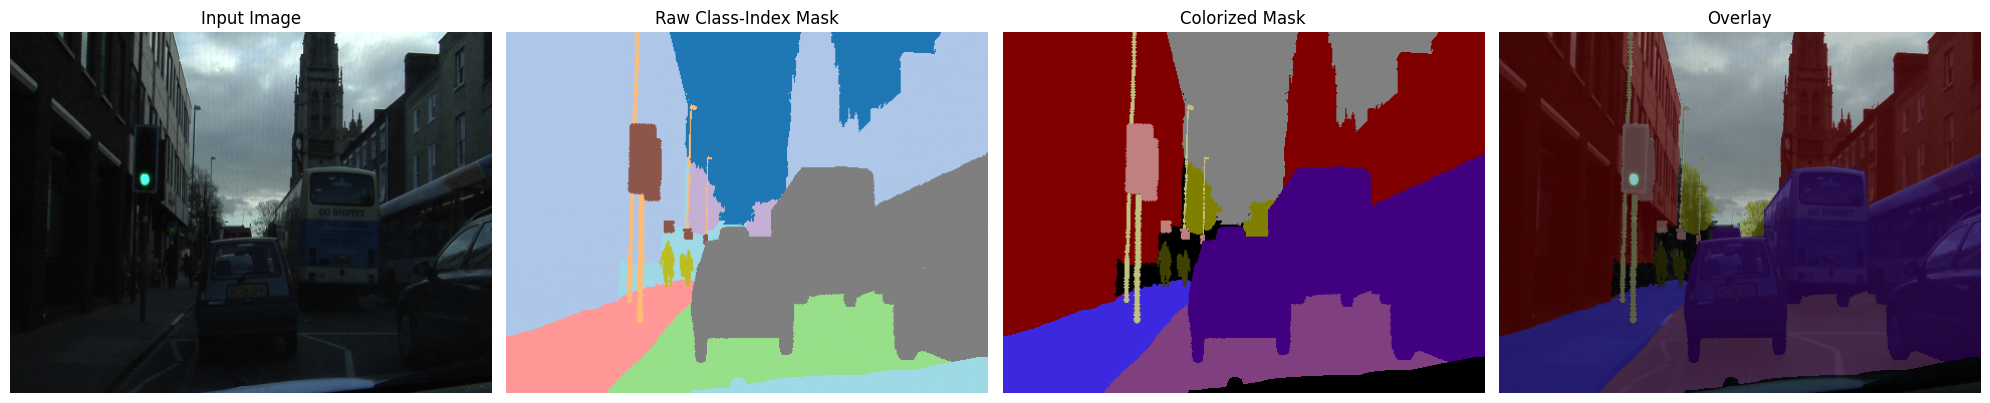

In [9]:
visualize_dataset_sample("camvid", split="train", sample_index=0)

In [10]:
visualize_dataset_sample("sensation", split="train", sample_index=0)

SENSATION train: image or mask folder does not exist yet.


## PyTorch Dataset and DataLoader

A custom PyTorch `Dataset` is used to load semantic segmentation image-mask pairs. Each image is resized, normalized, and converted into a tensor. Each mask is resized using nearest-neighbor interpolation to preserve integer class labels.

The same dataset class is reused for CamVid and SENSATION to ensure that both datasets follow the same preprocessing logic. This supports a fair comparison between FCN-ResNet50 and DeepLabV3+.

In [11]:
class SegmentationDataset(Dataset):
    def __init__(
        self,
        image_dir: Path,
        mask_dir: Path,
        image_size: int,
        num_classes: int,
        ignore_index: int | None = None,
    ):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_size = image_size
        self.num_classes = num_classes
        self.ignore_index = ignore_index

        self.image_paths = sorted(self.image_dir.glob("*.png"))

        if not self.image_paths:
            raise FileNotFoundError(f"No PNG images found in {self.image_dir}")

        self.samples = []

        for image_path in self.image_paths:
            mask_path = self.mask_dir / image_path.name

            if not mask_path.exists():
                raise FileNotFoundError(f"Missing mask for image: {image_path.name}")

            self.samples.append((image_path, mask_path))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        image_path, mask_path = self.samples[index]

        image = load_image_rgb(image_path)
        mask = load_mask_index(mask_path)

        if image.shape[:2] != mask.shape[:2]:
            raise ValueError(
                f"Image and mask dimensions do not match for {image_path.name}: "
                f"image={image.shape[:2]}, mask={mask.shape[:2]}"
            )

        image = cv2.resize(
            image,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR,
        )

        mask = cv2.resize(
            mask,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_NEAREST,
        )

        invalid_mask_values = set(np.unique(mask).astype(int).tolist()) - set(range(self.num_classes))

        if invalid_mask_values:
            raise ValueError(
                f"Invalid mask values in {mask_path.name}: {sorted(invalid_mask_values)}"
            )

        image = image.astype(np.float32) / 255.0

        # ImageNet normalization, appropriate for ResNet50 encoders pretrained on ImageNet.
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

        image = (image - mean) / std

        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(mask).long()

        return image_tensor, mask_tensor

In [29]:
def create_dataloaders(
    dataset_key: str,
    image_size: int = IMAGE_SIZE,
    batch_size: int = BATCH_SIZE,
    num_workers: int = NUM_WORKERS,
) -> dict[str, DataLoader]:
    config = DATASET_CONFIGS[dataset_key]

    dataloaders = {}

    for split in ["train", "val", "test"]:
        dataset = SegmentationDataset(
            image_dir=config["image_dirs"][split],
            mask_dir=config["mask_dirs"][split],
            image_size=image_size,
            num_classes=config["num_classes"],
            ignore_index=config["ignore_index"],
        )

        dataloaders[split] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(split == "train"),
            num_workers=num_workers,
            pin_memory=(DEVICE.type == "cuda"),
            drop_last=(split == "train"),
        )

        print(
            f"{config['name']} {split}: "
            f"{len(dataset)} samples, "
            f"{len(dataloaders[split])} batches"
        )

    return dataloaders

In [30]:
camvid_loaders = create_dataloaders("camvid")

CamVid train: 367 samples, 183 batches
CamVid val: 101 samples, 51 batches
CamVid test: 233 samples, 117 batches


In [31]:
images, masks = next(iter(camvid_loaders["train"]))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)
print("Mask min:", masks.min().item())
print("Mask max:", masks.max().item())

Image batch shape: torch.Size([2, 3, 384, 384])
Mask batch shape: torch.Size([2, 384, 384])
Image dtype: torch.float32
Mask dtype: torch.int64
Mask min: 0
Mask max: 11


## Model Architectures

Two semantic segmentation architectures are compared under the same experimental setting.

**FCN-ResNet50** uses a ResNet50 backbone and replaces the fully connected classification layers with convolutional layers, allowing dense pixel-level prediction. The architecture is simple and efficient, but it may produce less precise object boundaries because of repeated downsampling and upsampling.

**DeepLabV3+** uses an encoder-decoder structure with atrous spatial pyramid pooling. The ASPP module captures multi-scale contextual information, while the decoder helps recover spatial detail. This makes DeepLabV3+ especially suitable for urban scene segmentation where objects appear at different scales.

In [32]:
import segmentation_models_pytorch as smp


def create_fcn_resnet50(
    num_classes: int,
    pretrained: bool = True,
) -> nn.Module:
    if pretrained:
        weights = FCN_ResNet50_Weights.DEFAULT
    else:
        weights = None

    model = fcn_resnet50(weights=weights)

    # Replace the final classifier layer so the model predicts the correct number of classes.
    model.classifier[4] = nn.Conv2d(
        in_channels=512,
        out_channels=num_classes,
        kernel_size=1,
    )

    # Replace auxiliary classifier if it exists.
    if model.aux_classifier is not None:
        model.aux_classifier[4] = nn.Conv2d(
            in_channels=256,
            out_channels=num_classes,
            kernel_size=1,
        )

    return model


def create_deeplabv3plus(
    num_classes: int,
    encoder_name: str = "resnet50",
    encoder_weights: str | None = "imagenet",
) -> nn.Module:
    model = smp.DeepLabV3Plus(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=num_classes,
    )

    return model

In [33]:
def count_trainable_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def build_models_for_dataset(dataset_key: str) -> dict[str, nn.Module]:
    config = DATASET_CONFIGS[dataset_key]
    num_classes = config["num_classes"]

    models = {
        "FCN-ResNet50": create_fcn_resnet50(num_classes=num_classes),
        "DeepLabV3+": create_deeplabv3plus(num_classes=num_classes),
    }

    for model_name, model in models.items():
        models[model_name] = model.to(DEVICE)
        parameters = count_trainable_parameters(models[model_name])
        print(f"{model_name}: {parameters:,} trainable parameters")

    return models

In [34]:
camvid_models = build_models_for_dataset("camvid")

FCN-ResNet50: 35,315,288 trainable parameters
DeepLabV3+: 26,680,412 trainable parameters


## Loss Function, Optimizer, and Evaluation Metrics

Both models are optimized using the same loss function and optimizer settings to ensure a fair comparison. Since semantic segmentation is a multi-class pixel classification problem, Cross Entropy Loss is used.

The `Unlabelled` class in CamVid is treated as an ignored class. Pixels with this label do not contribute to the training loss or evaluation metrics.

The evaluation includes Pixel Accuracy, Mean Intersection over Union, Dice Score, Precision, Recall, and Inference Time.

In [35]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4


def create_loss_function(ignore_index: int | None = None) -> nn.Module:
    if ignore_index is None:
        return nn.CrossEntropyLoss()

    return nn.CrossEntropyLoss(ignore_index=ignore_index)


def create_optimizer(model: nn.Module) -> torch.optim.Optimizer:
    return torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )


def create_scheduler(optimizer: torch.optim.Optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )

In [36]:
def compute_segmentation_metrics(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    num_classes: int,
    ignore_index: int | None = None,
) -> dict[str, float]:
    predictions = predictions.detach().cpu()
    targets = targets.detach().cpu()

    if ignore_index is not None:
        valid_mask = targets != ignore_index
        predictions = predictions[valid_mask]
        targets = targets[valid_mask]

    if targets.numel() == 0:
        return {
            "pixel_accuracy": 0.0,
            "mean_iou": 0.0,
            "dice_score": 0.0,
            "precision": 0.0,
            "recall": 0.0,
        }

    pixel_accuracy = (predictions == targets).float().mean().item()

    iou_scores = []
    dice_scores = []
    precision_scores = []
    recall_scores = []

    for class_id in range(num_classes):
        if ignore_index is not None and class_id == ignore_index:
            continue

        pred_class = predictions == class_id
        target_class = targets == class_id

        true_positive = (pred_class & target_class).sum().item()
        false_positive = (pred_class & ~target_class).sum().item()
        false_negative = (~pred_class & target_class).sum().item()

        union = true_positive + false_positive + false_negative
        pred_total = true_positive + false_positive
        target_total = true_positive + false_negative

        if union > 0:
            iou_scores.append(true_positive / union)

        if pred_total + target_total > 0:
            dice_scores.append((2 * true_positive) / (pred_total + target_total))

        if pred_total > 0:
            precision_scores.append(true_positive / pred_total)

        if target_total > 0:
            recall_scores.append(true_positive / target_total)

    return {
        "pixel_accuracy": pixel_accuracy,
        "mean_iou": float(np.mean(iou_scores)) if iou_scores else 0.0,
        "dice_score": float(np.mean(dice_scores)) if dice_scores else 0.0,
        "precision": float(np.mean(precision_scores)) if precision_scores else 0.0,
        "recall": float(np.mean(recall_scores)) if recall_scores else 0.0,
    }

In [37]:
images, masks = next(iter(camvid_loaders["train"]))

images = images.to(DEVICE)
masks = masks.to(DEVICE)

model = camvid_models["FCN-ResNet50"]
model.eval()

with torch.no_grad():
    outputs = model(images)

    if isinstance(outputs, dict):
        outputs = outputs["out"]

    predictions = torch.argmax(outputs, dim=1)

metrics = compute_segmentation_metrics(
    predictions=predictions,
    targets=masks,
    num_classes=CAMVID_NUM_CLASSES,
    ignore_index=CAMVID_IGNORE_INDEX,
)

metrics

{'pixel_accuracy': 0.05980496108531952,
 'mean_iou': 0.012572986566251847,
 'dice_score': 0.023415271954834303,
 'precision': 0.12210431679413464,
 'recall': 0.1054791207620723}

## Training and Validation Procedure

The training loop updates model parameters using the training set, while the validation loop evaluates generalization performance without updating parameters. For each epoch, training loss, validation loss, and validation metrics are recorded.

The best model checkpoint is selected based on validation Mean IoU because mIoU is a standard metric for semantic segmentation and is less biased by dominant classes than pixel accuracy.

In [38]:
def get_model_output(model: nn.Module, images: torch.Tensor) -> torch.Tensor:
    outputs = model(images)

    # Torchvision segmentation models return a dictionary.
    # segmentation_models_pytorch models return the tensor directly.
    if isinstance(outputs, dict):
        outputs = outputs["out"]

    return outputs

In [39]:
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> float:
    model.train()
    running_loss = 0.0

    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = get_model_output(model, images)
        loss = loss_function(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)
    return epoch_loss

In [40]:
def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    loss_function: nn.Module,
    device: torch.device,
    num_classes: int,
    ignore_index: int | None = None,
) -> dict[str, float]:
    model.eval()

    running_loss = 0.0
    total_metrics = {
        "pixel_accuracy": 0.0,
        "mean_iou": 0.0,
        "dice_score": 0.0,
        "precision": 0.0,
        "recall": 0.0,
    }

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = get_model_output(model, images)
            loss = loss_function(outputs, masks)

            predictions = torch.argmax(outputs, dim=1)

            batch_metrics = compute_segmentation_metrics(
                predictions=predictions,
                targets=masks,
                num_classes=num_classes,
                ignore_index=ignore_index,
            )

            running_loss += loss.item()

            for metric_name in total_metrics:
                total_metrics[metric_name] += batch_metrics[metric_name]

    num_batches = len(dataloader)

    results = {
        "loss": running_loss / num_batches,
    }

    for metric_name, metric_value in total_metrics.items():
        results[metric_name] = metric_value / num_batches

    return results

In [41]:
def train_model(
    model: nn.Module,
    model_name: str,
    dataset_key: str,
    dataloaders: dict[str, DataLoader],
    num_epochs: int,
) -> pd.DataFrame:
    config = DATASET_CONFIGS[dataset_key]

    loss_function = create_loss_function(ignore_index=config["ignore_index"])
    optimizer = create_optimizer(model)
    scheduler = create_scheduler(optimizer)

    best_val_miou = -1.0
    history = []

    checkpoint_path = CHECKPOINTS_DIR / f"{dataset_key}_{model_name.replace(' ', '_').replace('+', 'plus')}_best.pth"

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss = train_one_epoch(
            model=model,
            dataloader=dataloaders["train"],
            loss_function=loss_function,
            optimizer=optimizer,
            device=DEVICE,
        )

        val_results = evaluate_model(
            model=model,
            dataloader=dataloaders["val"],
            loss_function=loss_function,
            device=DEVICE,
            num_classes=config["num_classes"],
            ignore_index=config["ignore_index"],
        )

        scheduler.step(val_results["mean_iou"])

        epoch_time = time.time() - start_time

        row = {
            "dataset": config["name"],
            "model": model_name,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_results["loss"],
            "val_pixel_accuracy": val_results["pixel_accuracy"],
            "val_mean_iou": val_results["mean_iou"],
            "val_dice_score": val_results["dice_score"],
            "val_precision": val_results["precision"],
            "val_recall": val_results["recall"],
            "epoch_time_sec": epoch_time,
        }

        history.append(row)

        print(
            f"[{config['name']} | {model_name}] "
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_results['loss']:.4f} | "
            f"Val mIoU: {val_results['mean_iou']:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )

        if val_results["mean_iou"] > best_val_miou:
            best_val_miou = val_results["mean_iou"]

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "model_name": model_name,
                    "dataset_key": dataset_key,
                    "epoch": epoch + 1,
                    "best_val_miou": best_val_miou,
                    "class_names": config["classes"],
                },
                checkpoint_path,
            )

            print(f"Saved best checkpoint: {checkpoint_path}")

    history_df = pd.DataFrame(history)
    history_csv_path = REPORTS_DIR / f"{dataset_key}_{model_name.replace(' ', '_').replace('+', 'plus')}_history.csv"
    history_df.to_csv(history_csv_path, index=False)

    return history_df

In [ ]:
NUM_EPOCHS = 25

fcn_history = train_model(
    model=camvid_models["FCN-ResNet50"],
    model_name="FCN-ResNet50",
    dataset_key="camvid",
    dataloaders=camvid_loaders,
    num_epochs=NUM_EPOCHS,
)

display(fcn_history)

[CamVid | FCN-ResNet50] Epoch 1/25 | Train Loss: 0.6092 | Val Loss: 0.3708 | Val mIoU: 0.4847 | Time: 41.3s
Saved best checkpoint: checkpoints\camvid_FCN-ResNet50_best.pth
[CamVid | FCN-ResNet50] Epoch 2/25 | Train Loss: 0.2913 | Val Loss: 0.3223 | Val mIoU: 0.5425 | Time: 39.9s
Saved best checkpoint: checkpoints\camvid_FCN-ResNet50_best.pth
[CamVid | FCN-ResNet50] Epoch 3/25 | Train Loss: 0.2139 | Val Loss: 0.2708 | Val mIoU: 0.6026 | Time: 39.5s
Saved best checkpoint: checkpoints\camvid_FCN-ResNet50_best.pth
[CamVid | FCN-ResNet50] Epoch 4/25 | Train Loss: 0.1792 | Val Loss: 0.2201 | Val mIoU: 0.6522 | Time: 39.7s
Saved best checkpoint: checkpoints\camvid_FCN-ResNet50_best.pth
[CamVid | FCN-ResNet50] Epoch 5/25 | Train Loss: 0.1458 | Val Loss: 0.2090 | Val mIoU: 0.6707 | Time: 38.6s
Saved best checkpoint: checkpoints\camvid_FCN-ResNet50_best.pth
[CamVid | FCN-ResNet50] Epoch 6/25 | Train Loss: 0.1267 | Val Loss: 0.2030 | Val mIoU: 0.6725 | Time: 38.5s
Saved best checkpoint: checkpoin

,dataset,model,epoch,train_loss,val_loss,val_pixel_accuracy,val_mean_iou,val_dice_score,val_precision,val_recall,epoch_time_sec
0,CamVid,FCN-ResNet50,1,0.609220,0.370778,0.882048,0.484676,0.547925,0.752961,0.574488,41.299949
1,CamVid,FCN-ResNet50,2,0.291284,0.322306,0.894349,0.542482,0.623679,0.744855,0.650666,39.897992
2,CamVid,FCN-ResNet50,3,0.213860,0.270785,0.913601,0.602556,0.687515,0.761573,0.690277,39.450216
3,CamVid,FCN-ResNet50,4,0.179205,0.220098,0.932708,0.652174,0.739000,0.773155,0.753389,39.704679
4,CamVid,FCN-ResNet50,5,0.145753,0.208988,0.933453,0.670684,0.752918,0.803580,0.750559,38.630907
5,CamVid,FCN-ResNet50,6,0.126712,0.203024,0.937681,0.672533,0.754488,0.794876,0.758702,38.512349
6,CamVid,FCN-ResNet50,7,0.112861,0.180001,0.942813,0.688375,0.770394,0.804800,0.780732,37.431187
7,CamVid,FCN-ResNet50,8,0.101759,0.175934,0.946302,0.703303,0.783943,0.813240,0.791714,37.193230
8,CamVid,FCN-ResNet50,9,0.095835,0.187056,0.940203,0.669269,0.755118,0.798485,0.764658,37.280147
9,CamVid,FCN-ResNet50,10,0.088762,0.189227,0.941298,0.696035,0.778819,0.810181,0.779517,37.098522


In [43]:
NUM_EPOCHS = 25
deeplab_history = train_model(
    model=camvid_models["DeepLabV3+"],
    model_name="DeepLabV3+",
    dataset_key="camvid",
    dataloaders=camvid_loaders,
    num_epochs=NUM_EPOCHS,
)

display(deeplab_history)

[CamVid | DeepLabV3+] Epoch 1/25 | Train Loss: 0.3678 | Val Loss: 0.3232 | Val mIoU: 0.4873 | Time: 21.8s
Saved best checkpoint: checkpoints\camvid_DeepLabV3plus_best.pth
[CamVid | DeepLabV3+] Epoch 2/25 | Train Loss: 0.2635 | Val Loss: 0.2817 | Val mIoU: 0.5334 | Time: 22.1s
Saved best checkpoint: checkpoints\camvid_DeepLabV3plus_best.pth
[CamVid | DeepLabV3+] Epoch 3/25 | Train Loss: 0.2161 | Val Loss: 0.2301 | Val mIoU: 0.5957 | Time: 22.0s
Saved best checkpoint: checkpoints\camvid_DeepLabV3plus_best.pth
[CamVid | DeepLabV3+] Epoch 4/25 | Train Loss: 0.1841 | Val Loss: 0.2182 | Val mIoU: 0.6315 | Time: 19.2s
Saved best checkpoint: checkpoints\camvid_DeepLabV3plus_best.pth
[CamVid | DeepLabV3+] Epoch 5/25 | Train Loss: 0.1676 | Val Loss: 0.2079 | Val mIoU: 0.6209 | Time: 19.1s
[CamVid | DeepLabV3+] Epoch 6/25 | Train Loss: 0.1538 | Val Loss: 0.2020 | Val mIoU: 0.6549 | Time: 19.0s
Saved best checkpoint: checkpoints\camvid_DeepLabV3plus_best.pth
[CamVid | DeepLabV3+] Epoch 7/25 | Trai

,dataset,model,epoch,train_loss,val_loss,val_pixel_accuracy,val_mean_iou,val_dice_score,val_precision,val_recall,epoch_time_sec
0,CamVid,DeepLabV3+,1,0.367828,0.323192,0.895795,0.487322,0.547408,0.700001,0.588025,21.768362
1,CamVid,DeepLabV3+,2,0.263521,0.281749,0.904610,0.533365,0.599197,0.738024,0.654197,22.081716
2,CamVid,DeepLabV3+,3,0.216119,0.230094,0.925781,0.595696,0.670936,0.723476,0.708863,22.011799
3,CamVid,DeepLabV3+,4,0.184146,0.218165,0.930434,0.631549,0.707662,0.747306,0.726137,19.197943
4,CamVid,DeepLabV3+,5,0.167623,0.207948,0.931814,0.620887,0.698555,0.751365,0.724765,19.058159
5,CamVid,DeepLabV3+,6,0.153803,0.202015,0.935417,0.654946,0.734066,0.764031,0.759136,19.034620
6,CamVid,DeepLabV3+,7,0.144681,0.185596,0.938939,0.640539,0.716509,0.777488,0.729021,19.123994
7,CamVid,DeepLabV3+,8,0.131956,0.179547,0.941621,0.656786,0.736798,0.789162,0.733344,19.066493
8,CamVid,DeepLabV3+,9,0.122849,0.185015,0.942047,0.682047,0.758746,0.799653,0.766778,19.052130
9,CamVid,DeepLabV3+,10,0.118850,0.180434,0.941618,0.650912,0.733438,0.787025,0.732479,19.389278


## Training and Validation Curves

Training and validation curves are used to analyze optimization behavior. The loss curves indicate whether the models are learning from the training data, while validation metrics show how well each model generalizes to unseen validation images.

These plots are used for academic comparison and are saved to the reports directory.

In [44]:
camvid_training_history = pd.concat(
    [fcn_history, deeplab_history],
    ignore_index=True,
)

display(camvid_training_history)

,dataset,model,epoch,train_loss,val_loss,val_pixel_accuracy,val_mean_iou,val_dice_score,val_precision,val_recall,epoch_time_sec
0,CamVid,FCN-ResNet50,1,0.609220,0.370778,0.882048,0.484676,0.547925,0.752961,0.574488,41.299949
1,CamVid,FCN-ResNet50,2,0.291284,0.322306,0.894349,0.542482,0.623679,0.744855,0.650666,39.897992
2,CamVid,FCN-ResNet50,3,0.213860,0.270785,0.913601,0.602556,0.687515,0.761573,0.690277,39.450216
3,CamVid,FCN-ResNet50,4,0.179205,0.220098,0.932708,0.652174,0.739000,0.773155,0.753389,39.704679
4,CamVid,FCN-ResNet50,5,0.145753,0.208988,0.933453,0.670684,0.752918,0.803580,0.750559,38.630907
5,CamVid,FCN-ResNet50,6,0.126712,0.203024,0.937681,0.672533,0.754488,0.794876,0.758702,38.512349
6,CamVid,FCN-ResNet50,7,0.112861,0.180001,0.942813,0.688375,0.770394,0.804800,0.780732,37.431187
7,CamVid,FCN-ResNet50,8,0.101759,0.175934,0.946302,0.703303,0.783943,0.813240,0.791714,37.193230
8,CamVid,FCN-ResNet50,9,0.095835,0.187056,0.940203,0.669269,0.755118,0.798485,0.764658,37.280147
9,CamVid,FCN-ResNet50,10,0.088762,0.189227,0.941298,0.696035,0.778819,0.810181,0.779517,37.098522


In [45]:
def plot_training_curves(
    history_df: pd.DataFrame,
    dataset_key: str,
) -> None:
    dataset_name = DATASET_CONFIGS[dataset_key]["name"]

    metrics_to_plot = [
        ("train_loss", "Training Loss"),
        ("val_loss", "Validation Loss"),
        ("val_mean_iou", "Validation Mean IoU"),
        ("val_pixel_accuracy", "Validation Pixel Accuracy"),
        ("val_dice_score", "Validation Dice Score"),
    ]

    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(24, 4))

    for axis, (metric_column, metric_title) in zip(axes, metrics_to_plot):
        for model_name in history_df["model"].unique():
            model_history = history_df[history_df["model"] == model_name]

            axis.plot(
                model_history["epoch"],
                model_history[metric_column],
                marker="o",
                label=model_name,
            )

        axis.set_title(metric_title)
        axis.set_xlabel("Epoch")
        axis.grid(True, alpha=0.3)

        if metric_column not in ["train_loss", "val_loss"]:
            axis.set_ylim(0, 1)

    axes[-1].legend(loc="lower right")

    plt.suptitle(f"{dataset_name}: Training and Validation Curves", fontsize=14)
    plt.tight_layout()

    output_path = REPORTS_DIR / f"{dataset_key}_training_validation_curves.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved curve figure to: {output_path}")

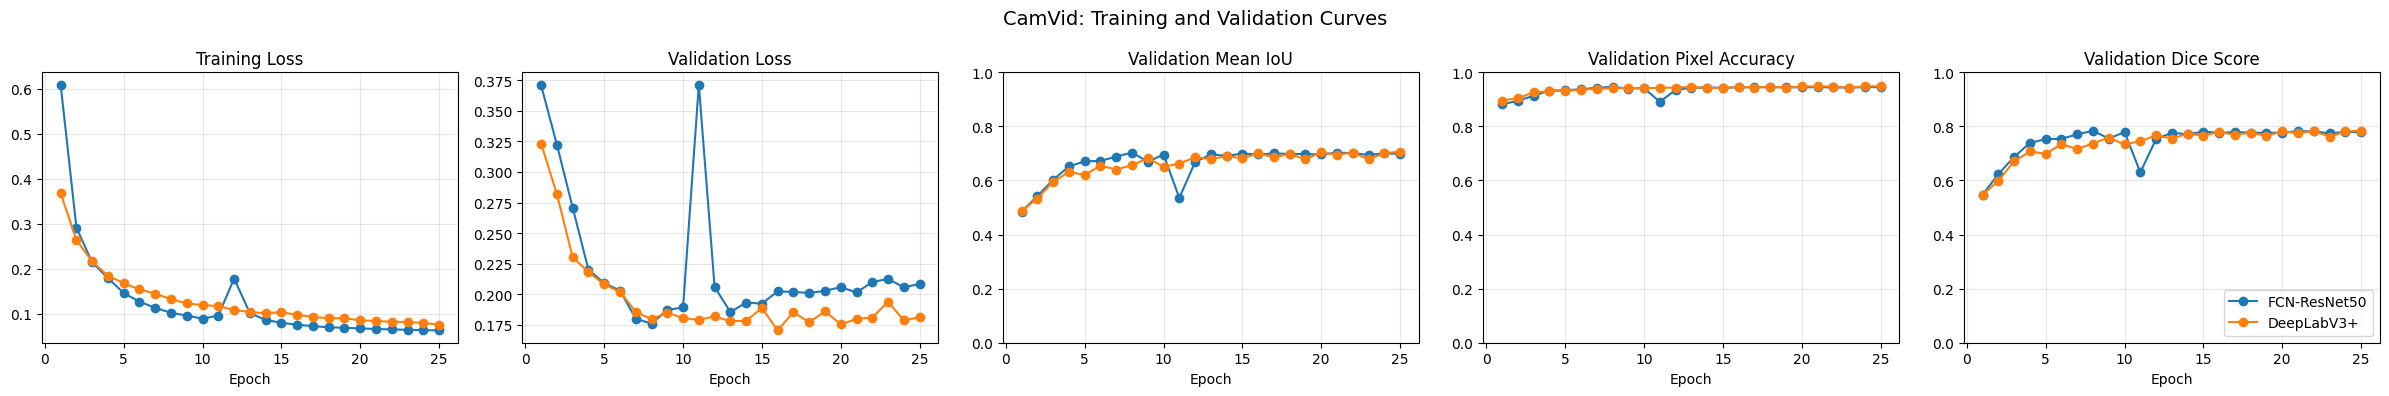

Saved curve figure to: reports\camvid_training_validation_curves.png


In [46]:
plot_training_curves(
    history_df=camvid_training_history,
    dataset_key="camvid",
)

In [47]:
def summarize_best_validation_results(history_df: pd.DataFrame) -> pd.DataFrame:
    best_rows = []

    for model_name in history_df["model"].unique():
        model_history = history_df[history_df["model"] == model_name]
        best_row = model_history.loc[model_history["val_mean_iou"].idxmax()]
        best_rows.append(best_row)

    summary = pd.DataFrame(best_rows)

    selected_columns = [
        "dataset",
        "model",
        "epoch",
        "val_loss",
        "val_pixel_accuracy",
        "val_mean_iou",
        "val_dice_score",
        "val_precision",
        "val_recall",
        "epoch_time_sec",
    ]

    summary = summary[selected_columns].sort_values(
        by="val_mean_iou",
        ascending=False,
    )

    return summary.reset_index(drop=True)

In [48]:
camvid_best_validation_summary = summarize_best_validation_results(camvid_training_history)

display(camvid_best_validation_summary)

summary_path = REPORTS_DIR / "camvid_best_validation_summary.csv"
camvid_best_validation_summary.to_csv(summary_path, index=False)

print(f"Saved validation summary to: {summary_path}")

,dataset,model,epoch,val_loss,val_pixel_accuracy,val_mean_iou,val_dice_score,val_precision,val_recall,epoch_time_sec
0,CamVid,DeepLabV3+,25,0.181226,0.949071,0.706271,0.783742,0.819296,0.792659,19.454099
1,CamVid,FCN-ResNet50,8,0.175934,0.946302,0.703303,0.783943,0.813240,0.791714,37.193230


Saved validation summary to: reports\camvid_best_validation_summary.csv


## Test-Set Evaluation

After model training, the best checkpoint for each architecture is loaded and evaluated on the test set. The test set is not used during optimization or checkpoint selection. This provides a more reliable estimate of final segmentation performance.

Inference time is also measured to compare computational efficiency between FCN-ResNet50 and DeepLabV3+.

In [64]:
def load_best_checkpoint(
    model: nn.Module,
    checkpoint_path: Path,
    device: torch.device,
) -> nn.Module:
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    print(
        f"Loaded checkpoint: {checkpoint_path} "
        f"(epoch={checkpoint['epoch']}, best_val_mIoU={checkpoint['best_val_miou']:.4f})"
    )

    return model

In [65]:
def measure_batch_inference_time(
    model: nn.Module,
    images: torch.Tensor,
    device: torch.device,
) -> float:
    model.eval()

    images = images.to(device)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()

    with torch.no_grad():
        _ = get_model_output(model, images)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed_time = time.time() - start_time

    return elapsed_time / images.size(0)

In [66]:
def evaluate_on_test_set(
    model: nn.Module,
    model_name: str,
    dataset_key: str,
    dataloader: DataLoader,
) -> dict[str, float | str]:
    config = DATASET_CONFIGS[dataset_key]

    loss_function = create_loss_function(ignore_index=config["ignore_index"])

    test_results = evaluate_model(
        model=model,
        dataloader=dataloader,
        loss_function=loss_function,
        device=DEVICE,
        num_classes=config["num_classes"],
        ignore_index=config["ignore_index"],
    )

    inference_times = []

    with torch.no_grad():
        for images, _ in dataloader:
            batch_time = measure_batch_inference_time(
                model=model,
                images=images,
                device=DEVICE,
            )
            inference_times.append(batch_time)

    result = {
        "dataset": config["name"],
        "model": model_name,
        "test_loss": test_results["loss"],
        "test_pixel_accuracy": test_results["pixel_accuracy"],
        "test_mean_iou": test_results["mean_iou"],
        "test_dice_score": test_results["dice_score"],
        "test_precision": test_results["precision"],
        "test_recall": test_results["recall"],
        "inference_time_sec_per_image": float(np.mean(inference_times)),
    }

    return result

In [67]:
camvid_best_fcn_path = CHECKPOINTS_DIR / "camvid_FCN-ResNet50_best.pth"
camvid_best_deeplab_path = CHECKPOINTS_DIR / "camvid_DeepLabV3plus_best.pth"

camvid_models["FCN-ResNet50"] = load_best_checkpoint(
    model=camvid_models["FCN-ResNet50"],
    checkpoint_path=camvid_best_fcn_path,
    device=DEVICE,
)

camvid_models["DeepLabV3+"] = load_best_checkpoint(
    model=camvid_models["DeepLabV3+"],
    checkpoint_path=camvid_best_deeplab_path,
    device=DEVICE,
)

Loaded checkpoint: checkpoints\camvid_FCN-ResNet50_best.pth (epoch=8, best_val_mIoU=0.7033)
Loaded checkpoint: checkpoints\camvid_DeepLabV3plus_best.pth (epoch=25, best_val_mIoU=0.7063)


In [68]:
camvid_test_results = []

for model_name, model in camvid_models.items():
    result = evaluate_on_test_set(
        model=model,
        model_name=model_name,
        dataset_key="camvid",
        dataloader=camvid_loaders["test"],
    )

    camvid_test_results.append(result)

camvid_test_results_df = pd.DataFrame(camvid_test_results)

camvid_test_results_df = camvid_test_results_df.sort_values(
    by="test_mean_iou",
    ascending=False,
).reset_index(drop=True)

display(camvid_test_results_df)

test_results_path = REPORTS_DIR / "camvid_test_results.csv"
camvid_test_results_df.to_csv(test_results_path, index=False)

print(f"Saved test results to: {test_results_path}")

,dataset,model,test_loss,test_pixel_accuracy,test_mean_iou,test_dice_score,test_precision,test_recall,inference_time_sec_per_image
0,CamVid,DeepLabV3+,0.331919,0.914613,0.575514,0.657902,0.718068,0.702700,0.008778
1,CamVid,FCN-ResNet50,0.314978,0.903962,0.565094,0.649498,0.696880,0.698814,0.023687


Saved test results to: reports\camvid_test_results.csv


## Qualitative Segmentation Results

Qualitative results are visualized to compare the spatial behavior of FCN-ResNet50 and DeepLabV3+. While quantitative metrics summarize performance numerically, prediction masks reveal model behavior around object boundaries, thin structures, small objects, and visually ambiguous regions.

For each selected test image, the input image, ground-truth mask, FCN-ResNet50 prediction, and DeepLabV3+ prediction are displayed side by side.

In [69]:
def predict_mask(
    model: nn.Module,
    image_tensor: torch.Tensor,
    device: torch.device,
) -> np.ndarray:
    model.eval()

    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        output = get_model_output(model, image_tensor)
        prediction = torch.argmax(output, dim=1)

    return prediction.squeeze(0).cpu().numpy().astype(np.int64)

In [70]:
def denormalize_image(image_tensor: torch.Tensor) -> np.ndarray:
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    image = (image * std) + mean
    image = np.clip(image, 0, 1)

    return (image * 255).astype(np.uint8)

In [71]:
def visualize_model_predictions(
    dataset_key: str,
    dataloader: DataLoader,
    models: dict[str, nn.Module],
    sample_count: int = 4,
) -> None:
    config = DATASET_CONFIGS[dataset_key]
    palette = config["palette"]

    dataset = dataloader.dataset

    fig, axes = plt.subplots(
        sample_count,
        2 + len(models),
        figsize=(5 * (2 + len(models)), 4 * sample_count),
    )

    if sample_count == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index in range(sample_count):
        image_tensor, mask_tensor = dataset[row_index]

        image = denormalize_image(image_tensor)
        ground_truth = mask_tensor.numpy()
        ground_truth_color = colorize_mask(ground_truth, palette)

        axes[row_index, 0].imshow(image)
        axes[row_index, 0].set_title("Input Image")
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(ground_truth_color)
        axes[row_index, 1].set_title("Ground Truth")
        axes[row_index, 1].axis("off")

        for model_col, (model_name, model) in enumerate(models.items(), start=2):
            prediction = predict_mask(
                model=model,
                image_tensor=image_tensor,
                device=DEVICE,
            )

            prediction_color = colorize_mask(prediction, palette)

            axes[row_index, model_col].imshow(prediction_color)
            axes[row_index, model_col].set_title(model_name)
            axes[row_index, model_col].axis("off")

    plt.tight_layout()

    output_path = REPORTS_DIR / f"{dataset_key}_qualitative_predictions.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved qualitative prediction figure to: {output_path}")

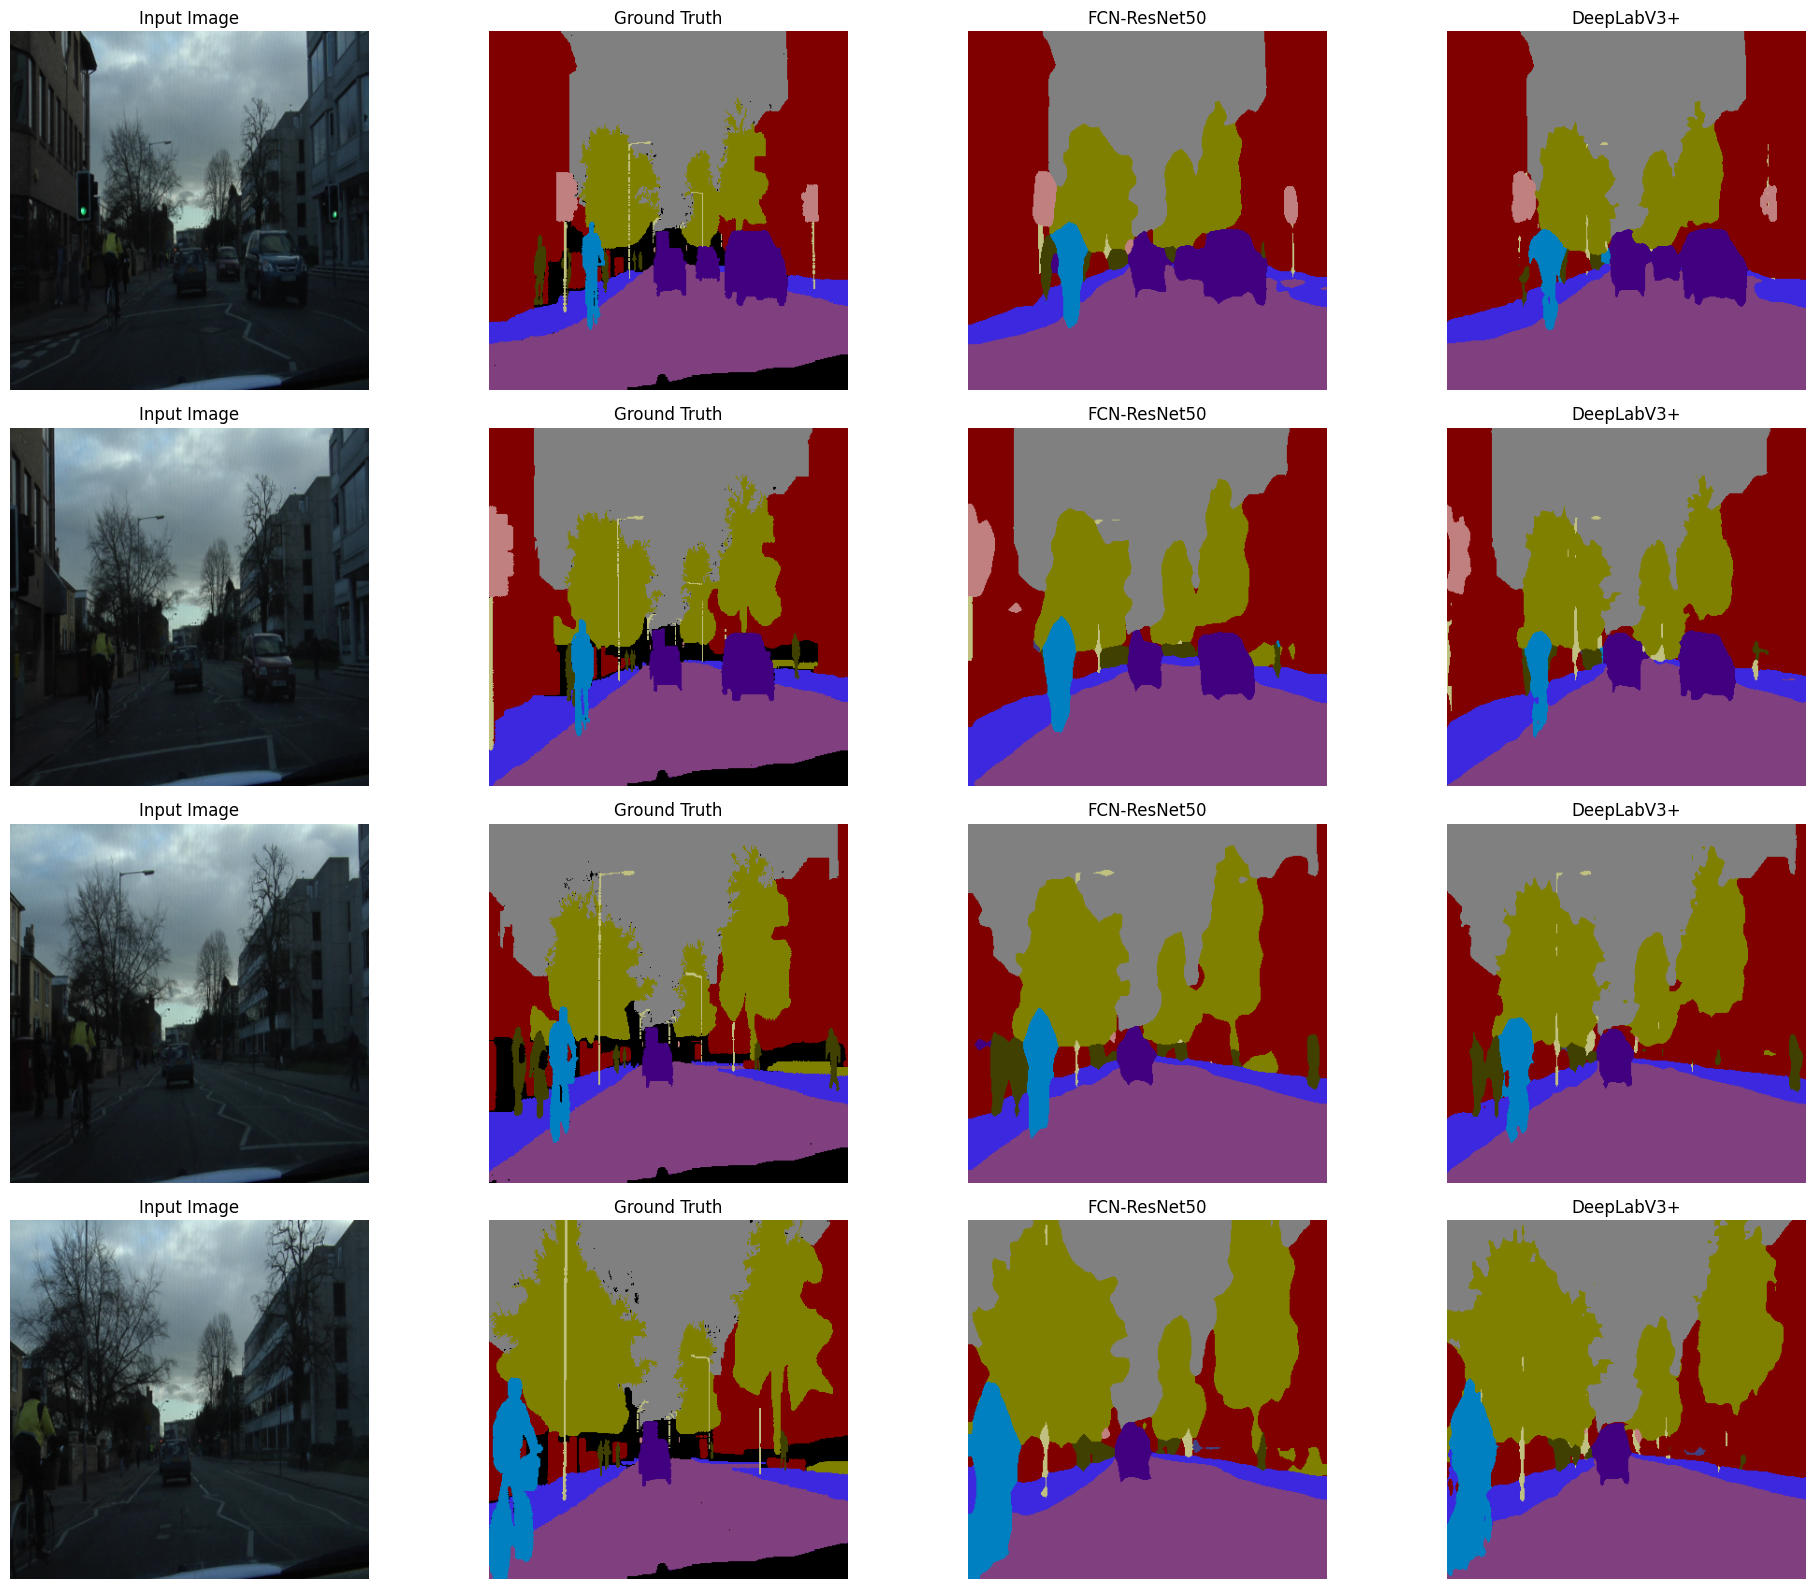

Saved qualitative prediction figure to: reports\camvid_qualitative_predictions.png


In [72]:
visualize_model_predictions(
    dataset_key="camvid",
    dataloader=camvid_loaders["test"],
    models=camvid_models,
    sample_count=4,
)

## Quantitative Metric Comparison

The final quantitative comparison is summarized using bar charts for the main test-set metrics. These visualizations make it easier to compare segmentation accuracy, overlap quality, classification balance, and computational efficiency between FCN-ResNet50 and DeepLabV3+.

In [73]:
def plot_test_metric_comparison(
    results_df: pd.DataFrame,
    dataset_key: str,
) -> None:
    dataset_name = DATASET_CONFIGS[dataset_key]["name"]

    metric_columns = [
        ("test_pixel_accuracy", "Pixel Accuracy"),
        ("test_mean_iou", "Mean IoU"),
        ("test_dice_score", "Dice Score"),
        ("test_precision", "Precision"),
        ("test_recall", "Recall"),
        ("inference_time_sec_per_image", "Inference Time / Image (s)"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for axis, (column, title) in zip(axes, metric_columns):
        axis.bar(
            results_df["model"],
            results_df[column],
            color=["#4C78A8", "#F58518"],
        )

        axis.set_title(title)
        axis.set_xlabel("Model")
        axis.grid(axis="y", alpha=0.3)

        if column != "inference_time_sec_per_image":
            axis.set_ylim(0, 1)

        for index, value in enumerate(results_df[column]):
            axis.text(
                index,
                value,
                f"{value:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.suptitle(f"{dataset_name}: Test Metric Comparison", fontsize=14)
    plt.tight_layout()

    output_path = REPORTS_DIR / f"{dataset_key}_test_metric_comparison.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved metric comparison chart to: {output_path}")

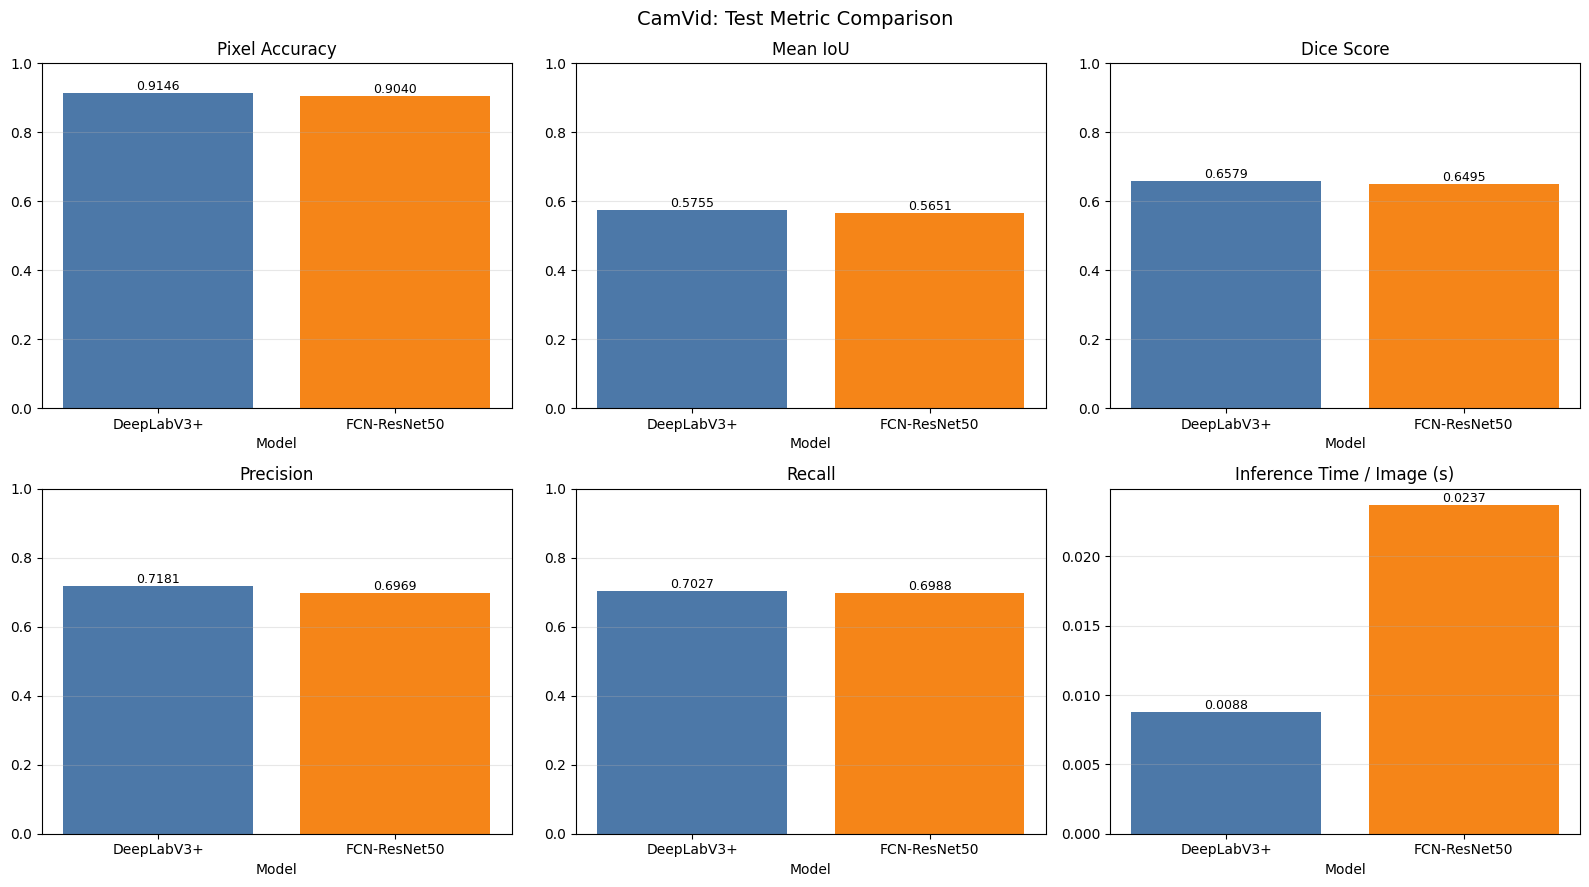

Saved metric comparison chart to: reports\camvid_test_metric_comparison.png


In [74]:
plot_test_metric_comparison(
    results_df=camvid_test_results_df,
    dataset_key="camvid",
)

In [75]:
display(
    camvid_test_results_df[
        [
            "model",
            "test_pixel_accuracy",
            "test_mean_iou",
            "test_dice_score",
            "test_precision",
            "test_recall",
            "inference_time_sec_per_image",
        ]
    ]
)

,model,test_pixel_accuracy,test_mean_iou,test_dice_score,test_precision,test_recall,inference_time_sec_per_image
0,DeepLabV3+,0.914613,0.575514,0.657902,0.718068,0.702700,0.008778
1,FCN-ResNet50,0.903962,0.565094,0.649498,0.696880,0.698814,0.023687


## Discussion

The CamVid experiment compares FCN-ResNet50 and DeepLabV3+ under the same data split, preprocessing, optimization settings, and evaluation protocol. Both models use a ResNet50 backbone with ImageNet-pretrained weights, so the comparison mainly reflects the effect of the segmentation head and decoder design.

The final experiment used an input size of 384 x 384 with a batch size of 2. This higher input resolution preserved more spatial detail than the earlier 256 x 256 trial and improved the test performance of both architectures. This is especially relevant for CamVid because several semantic classes, such as poles, signs, pedestrians, and bicyclists, occupy small image regions.

On the test set, DeepLabV3+ obtained the strongest overall result, with a Mean IoU of 0.5755 compared with 0.5651 for FCN-ResNet50. DeepLabV3+ also achieved a higher Dice Score, 0.6579 compared with 0.6495, and a higher Pixel Accuracy, 0.9146 compared with 0.9040. The margin is not large, but it consistently favors DeepLabV3+ across the main overlap and accuracy metrics.

FCN-ResNet50 remained competitive despite its simpler decoder structure. Its results show that a fully convolutional ResNet50-based model can still learn effective urban-scene segmentation features. However, the modest advantage of DeepLabV3+ is consistent with its architectural design, where multi-scale context aggregation and decoder refinement are intended to improve dense prediction quality.

The inference-time comparison shows a clearer practical difference. DeepLabV3+ required approximately 0.0090 seconds per image, while FCN-ResNet50 required approximately 0.0239 seconds per image in this experiment. Under the current implementation and hardware setting, DeepLabV3+ was both slightly more accurate and faster at inference.

The qualitative predictions should be considered alongside the numerical metrics. In urban-scene segmentation, visual inspection is important because thin structures, object boundaries, pedestrians, bicyclists, signs, and poles may not be fully represented by global metrics alone. The prediction examples therefore help identify whether the models mainly differ in large-region consistency, boundary quality, or small-object recognition.

## Limitations and Future Work

This experiment is limited by the size and class distribution of CamVid. Some classes appear much less frequently than road, building, and sky, which can reduce performance on small or rare objects. The current evaluation reports aggregate metrics; per-class IoU would provide a more detailed view of which semantic categories are most difficult for each model.

The comparison should also be extended to the SENSATION dataset after its images and masks are added and verified. This is necessary because conclusions from CamVid alone may not generalize to a dataset with different image sources, class frequencies, annotation quality, or scene composition.

Future improvements could include class-weighted loss, stronger data augmentation, per-class IoU analysis, and alternative backbones. Higher input resolution improved the CamVid results in this experiment, but further increases should be tested carefully because they increase memory usage and training time. Any such changes should be applied equally to both architectures to preserve a fair comparison.